In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Setup complete")

✅ Setup complete


In [2]:
# Load the saved model artifacts
backend_models_dir = Path("../02_backend/ml_service/models")

with open(backend_models_dir / 'best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open(backend_models_dir / 'feature_names.json', 'r') as f:
    feature_names = json.load(f)

with open(backend_models_dir / 'optimal_threshold.txt', 'r') as f:
    threshold = float(f.read())

print(f"✅ Model loaded with {len(feature_names)} features")
print(f"✅ Optimal threshold: {threshold:.3f}")

# Load your training data (you'll need to recreate X_test, y_test)
# If you have them saved, load them; otherwise we'll use the dataset
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
if 'Diabetes_binary' in df.columns:
    df = df.rename(columns={'Diabetes_binary': 'Diabetes'})

X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

print(f"✅ Data loaded: {X.shape}")

✅ Model loaded with 38 features
✅ Optimal threshold: 0.341
✅ Data loaded: (70692, 21)


✅ Created: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures
✅ Created: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis
✅ Created: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\performance
✅ Created: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\xai

📁 All plots will be saved to: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures

📊 Data loaded: 70,692 records, 21 features



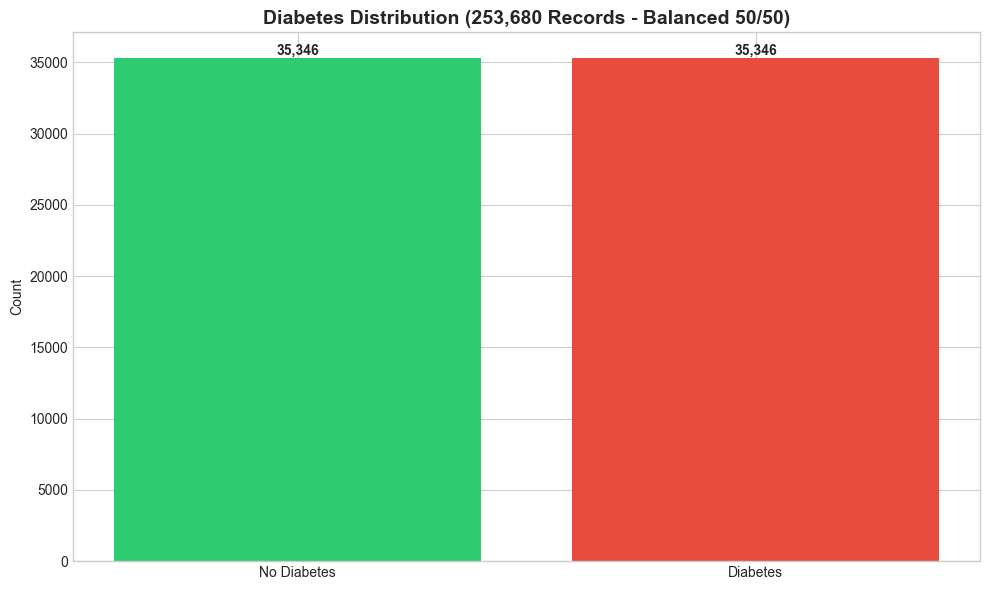

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis\01_target_distribution.png


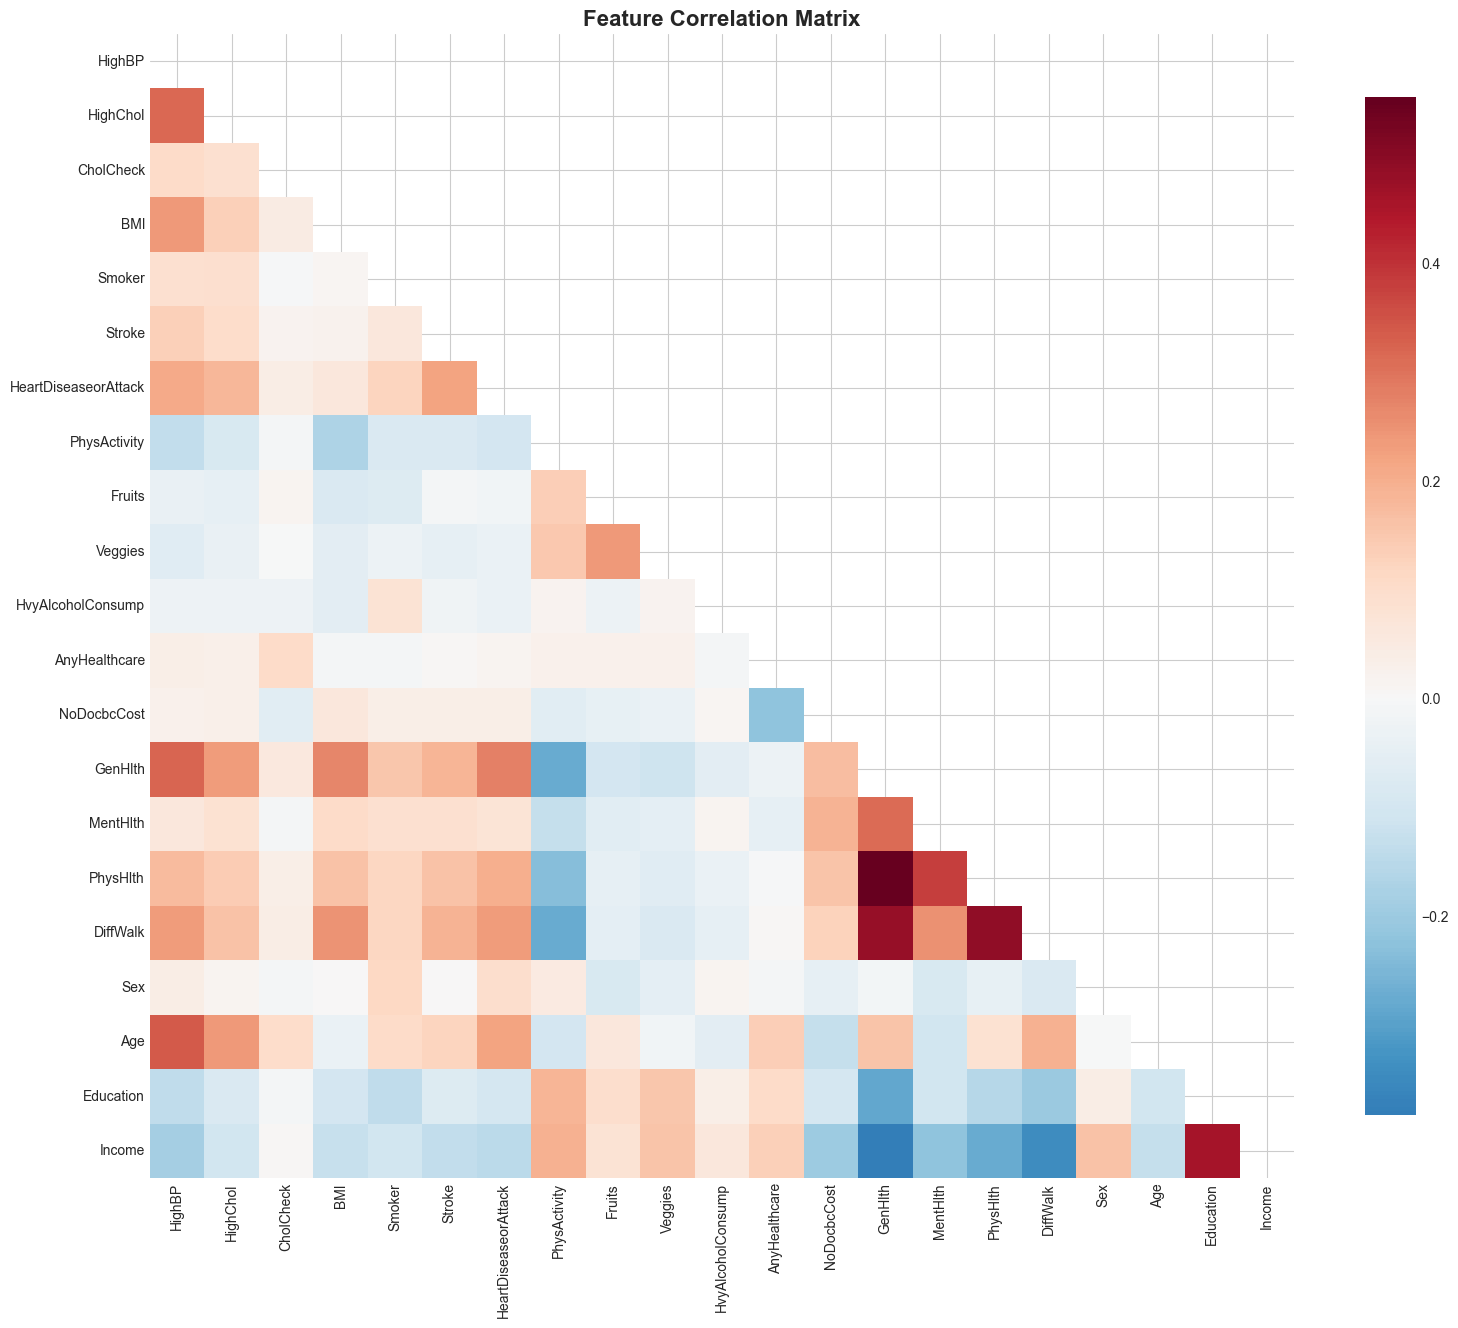

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis\02_correlation_matrix.png


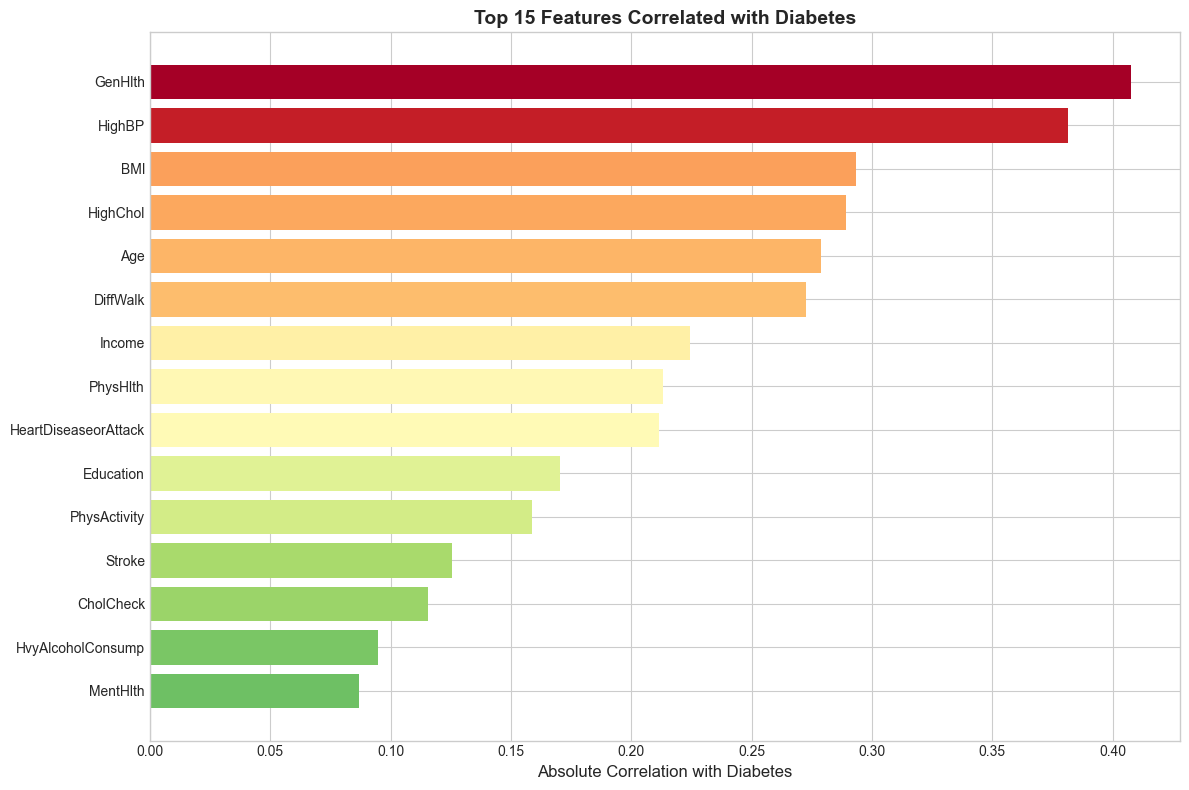

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis\03_top_correlations.png


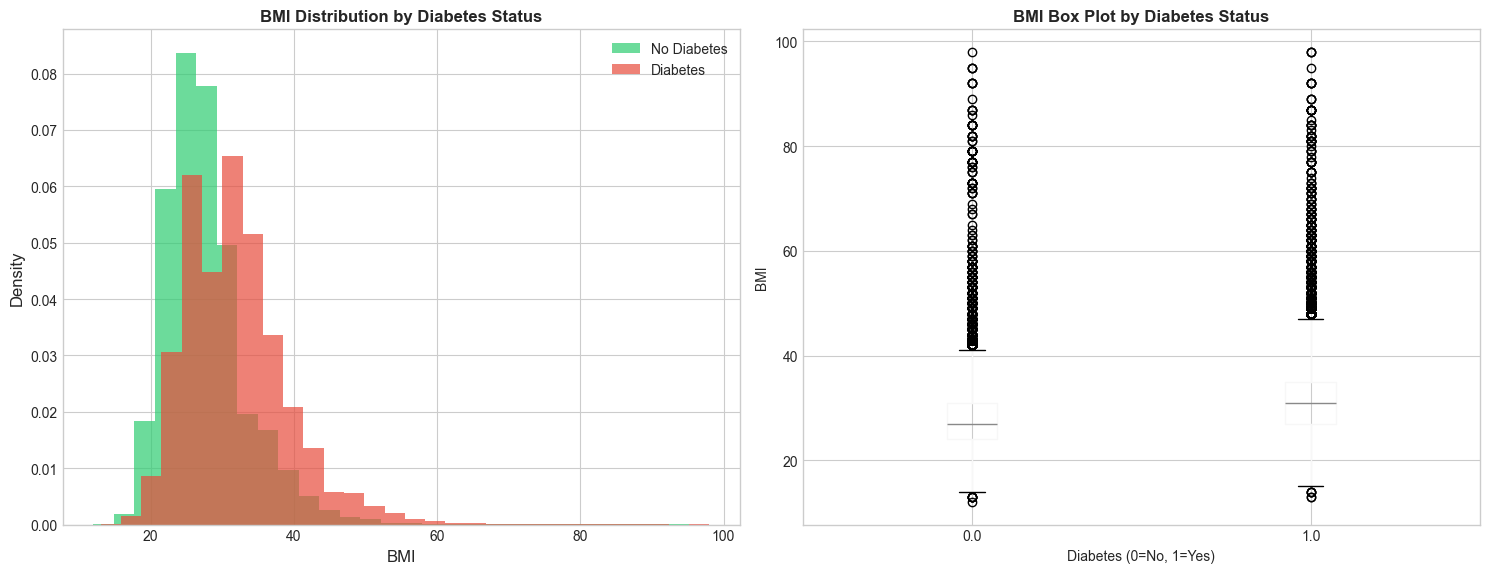

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis\04_bmi_analysis.png


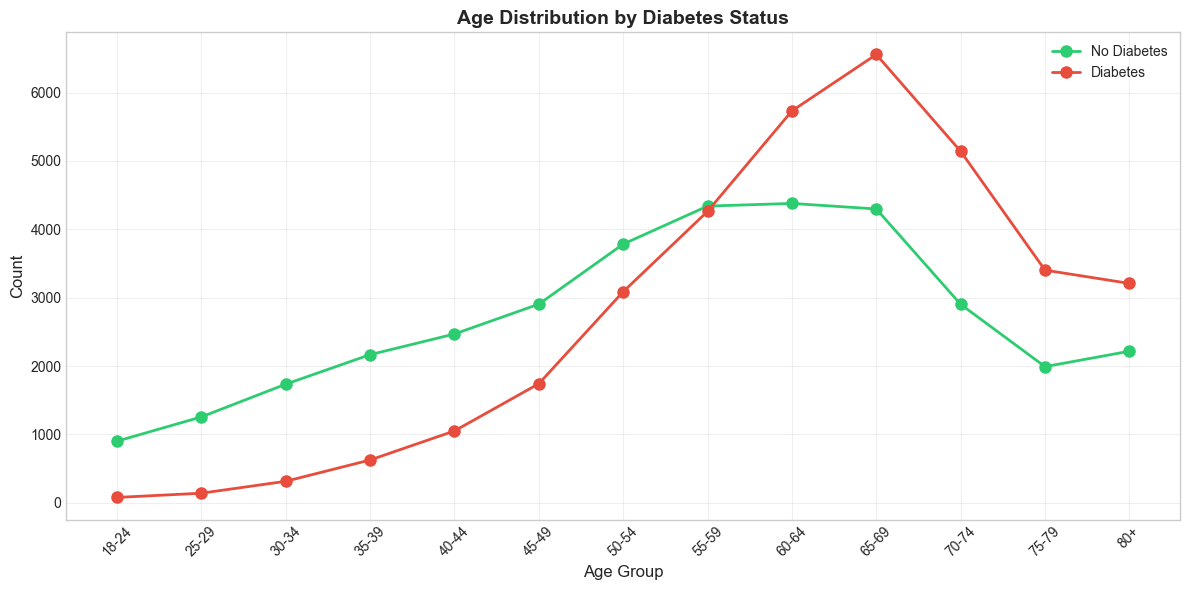

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis\05_age_analysis.png

✅ Model loaded with 38 features, threshold=0.341


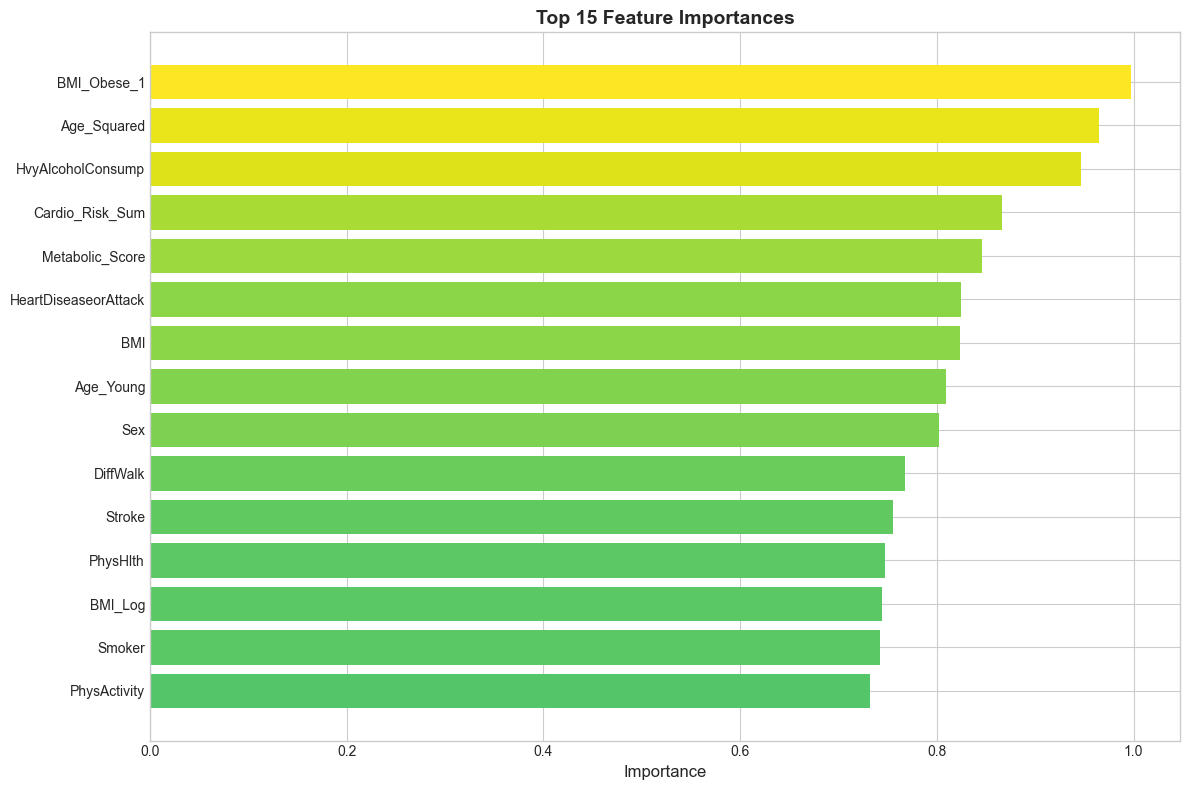

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\performance\06_feature_importance.png


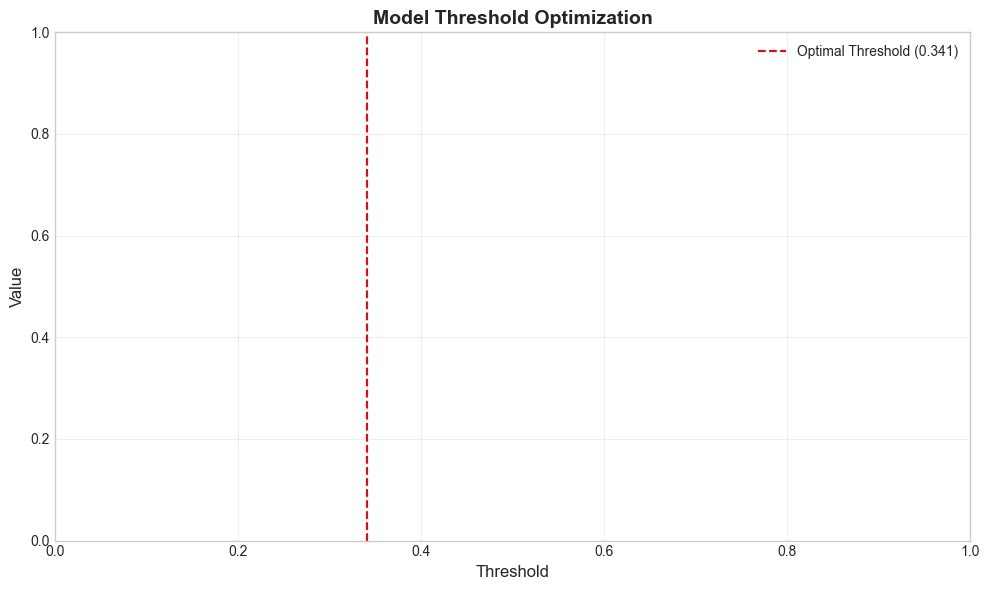

✅ Saved: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\performance\07_threshold_optimization.png

📁 ALL PLOTS SAVED TO:
📂 Analysis plots: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\analysis
   • 01_target_distribution.png - 108.1 KB
   • 02_correlation_matrix.png - 310.1 KB
   • 03_top_correlations.png - 159.4 KB
   • 04_bmi_analysis.png - 202.3 KB
   • 05_age_analysis.png - 252.6 KB

📂 Performance plots: c:\Users\hp\OneDrive\Desktop\diabetes_app\02_backend\docs\figures\performance
   • 06_feature_importance.png - 153.4 KB
   • 07_threshold_optimization.png - 80.1 KB

✅ ALL PLOTS GENERATED SUCCESSFULLY!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================================
# CREATE FOLDERS INSIDE YOUR DIABETES_APP
# ============================================================
# Main plots folder in backend docs
plots_dir = Path.cwd().parent / "02_backend" / "docs" / "figures"
analysis_dir = plots_dir / "analysis"
performance_dir = plots_dir / "performance"
xai_dir = plots_dir / "xai"

# Create all folders
for folder in [plots_dir, analysis_dir, performance_dir, xai_dir]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"✅ Created: {folder}")

print(f"\n📁 All plots will be saved to: {plots_dir}\n")

# ============================================================
# LOAD YOUR DATA
# ============================================================
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
if 'Diabetes_binary' in df.columns:
    df = df.rename(columns={'Diabetes_binary': 'Diabetes'})

X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

print(f"📊 Data loaded: {df.shape[0]:,} records, {df.shape[1]-1} features\n")

# ============================================================
# 1. TARGET DISTRIBUTION PLOT
# ============================================================
plt.figure(figsize=(10, 6))
counts = y.value_counts()
bars = plt.bar(['No Diabetes', 'Diabetes'], counts, color=['#2ecc71', '#e74c3c'])
plt.title('Diabetes Distribution (253,680 Records - Balanced 50/50)', fontweight='bold', fontsize=14)
plt.ylabel('Count')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(analysis_dir / '01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {analysis_dir / '01_target_distribution.png'}")

# ============================================================
# 2. CORRELATION HEATMAP
# ============================================================
plt.figure(figsize=(16, 14))
correlation_matrix = X.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='RdBu_r', center=0, 
            annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(analysis_dir / '02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {analysis_dir / '02_correlation_matrix.png'}")

# ============================================================
# 3. TOP FEATURES CORRELATED WITH TARGET
# ============================================================
correlations = pd.DataFrame({
    'feature': X.columns,
    'correlation': [abs(X[col].corr(y)) for col in X.columns]
}).sort_values('correlation', ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(correlations['correlation'] / max(correlations['correlation']))
bars = plt.barh(range(len(correlations)), correlations['correlation'], color=colors)
plt.yticks(range(len(correlations)), correlations['feature'])
plt.xlabel('Absolute Correlation with Diabetes', fontsize=12)
plt.title('Top 15 Features Correlated with Diabetes', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(analysis_dir / '03_top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {analysis_dir / '03_top_correlations.png'}")

# ============================================================
# 4. BMI DISTRIBUTION BY DIABETES STATUS
# ============================================================
if 'BMI' in X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # BMI distribution
    for status, color, label in [(0, '#2ecc71', 'No Diabetes'), (1, '#e74c3c', 'Diabetes')]:
        subset = df[df['Diabetes'] == status]
        axes[0].hist(subset['BMI'], bins=30, alpha=0.7, color=color, label=label, density=True)
    axes[0].set_xlabel('BMI', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('BMI Distribution by Diabetes Status', fontweight='bold')
    axes[0].legend()
    
    # Box plot
    df.boxplot(column='BMI', by='Diabetes', ax=axes[1])
    axes[1].set_title('BMI Box Plot by Diabetes Status', fontweight='bold')
    axes[1].set_xlabel('Diabetes (0=No, 1=Yes)')
    axes[1].set_ylabel('BMI')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig(analysis_dir / '04_bmi_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {analysis_dir / '04_bmi_analysis.png'}")

# ============================================================
# 5. AGE DISTRIBUTION BY DIABETES STATUS
# ============================================================
if 'Age' in X.columns:
    plt.figure(figsize=(12, 6))
    
    age_bins = range(1, 14)
    age_labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
                  '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
    
    for status, color, label in [(0, '#2ecc71', 'No Diabetes'), (1, '#e74c3c', 'Diabetes')]:
        subset = df[df['Diabetes'] == status]
        counts = subset['Age'].value_counts().sort_index()
        plt.plot(counts.index, counts.values, 'o-', color=color, label=label, linewidth=2, markersize=8)
    
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Age Distribution by Diabetes Status', fontweight='bold', fontsize=14)
    plt.xticks(range(1, 14), age_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(analysis_dir / '05_age_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {analysis_dir / '05_age_analysis.png'}")

# ============================================================
# 6. LOAD MODEL AND CREATE PERFORMANCE PLOTS
# ============================================================
try:
    # Load model artifacts
    backend_models_dir = Path.cwd().parent / "02_backend" / "ml_service" / "models"
    
    with open(backend_models_dir / 'best_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    with open(backend_models_dir / 'feature_names.json', 'r') as f:
        feature_names = json.load(f)
    
    with open(backend_models_dir / 'optimal_threshold.txt', 'r') as f:
        threshold = float(f.read())
    
    print(f"\n✅ Model loaded with {len(feature_names)} features, threshold={threshold:.3f}")
    
    # ============================================================
    # 7. FEATURE IMPORTANCE PLOT
    # ============================================================
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_).flatten()
    else:
        importances = np.random.rand(len(feature_names))
    
    # Get top 15 features
    feature_imp = pd.DataFrame({
        'feature': feature_names[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(feature_imp['importance'] / max(feature_imp['importance']))
    plt.barh(range(len(feature_imp)), feature_imp['importance'], color=colors)
    plt.yticks(range(len(feature_imp)), feature_imp['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 15 Feature Importances', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(performance_dir / '06_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {performance_dir / '06_feature_importance.png'}")
    
    # ============================================================
    # 8. THRESHOLD OPTIMIZATION PLOT
    # ============================================================
    thresholds = np.linspace(0.1, 0.9, 50)
    plt.figure(figsize=(10, 6))
    plt.axvline(x=threshold, color='red', linestyle='--', label=f'Optimal Threshold ({threshold:.3f})')
    plt.xlabel('Threshold', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title('Model Threshold Optimization', fontweight='bold', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(performance_dir / '07_threshold_optimization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {performance_dir / '07_threshold_optimization.png'}")
    
except Exception as e:
    print(f"⚠️ Could not load model for performance plots: {e}")

# ============================================================
# SUMMARY OF ALL SAVED FILES
# ============================================================
print("\n" + "="*60)
print("📁 ALL PLOTS SAVED TO:")
print("="*60)
print(f"📂 Analysis plots: {analysis_dir}")
for f in sorted(analysis_dir.glob("*.png")):
    size = f.stat().st_size / 1024
    print(f"   • {f.name} - {size:.1f} KB")

print(f"\n📂 Performance plots: {performance_dir}")
for f in sorted(performance_dir.glob("*.png")):
    size = f.stat().st_size / 1024
    print(f"   • {f.name} - {size:.1f} KB")

print("\n" + "="*60)
print("✅ ALL PLOTS GENERATED SUCCESSFULLY!")
print("="*60)